# Paper-ready CV summary table

Load one completed CV experiment and export a booktabs LaTeX table for the 15-bp realised-depeg definition and the chosen false-alert budget. Operational metrics include event/calendar-block bootstrap 95% confidence intervals; AUC and AUPRC are secondary row-level ranking metrics.

In [1]:
from pathlib import Path
import json
import sys
import warnings
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / 'cv_model_comparison.py').exists():
    PROJECT_DIR = PROJECT_DIR / '8. Early-Warning Model'
if not (PROJECT_DIR / 'cv_model_comparison.py').exists():
    raise FileNotFoundError('Run this notebook from the repository root or 8. Early-Warning Model.')
sys.path.insert(0, str(PROJECT_DIR))
from early_warning_evaluation import depeg_event_starts

# ---- Edit these values ----------------------------------------------------
EXPERIMENT_NAME = 'cv_model_comparison_2026-09-23_15bp'
DEPEG_THRESHOLD_BPS = 15.0
FALSE_ALERT_BUDGET = 2.0
LOG_DIR = PROJECT_DIR / 'lightning_logs'
EXPERIMENT_DIR = LOG_DIR / EXPERIMENT_NAME
if not EXPERIMENT_DIR.exists():
    available = sorted(p.name for p in LOG_DIR.glob('cv_model_comparison*') if p.is_dir())
    raise FileNotFoundError(f'{EXPERIMENT_DIR} does not exist. Available experiments: {available[-10:]}')
OUTPUT_DIR = EXPERIMENT_DIR / 'paper_ready'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
def read_latest(files, keys):
    frames = []
    for path in files:
        frame = pd.read_csv(path)
        if not frame.empty:
            frame['_source_mtime'] = path.stat().st_mtime
            frames.append(frame)
    if not frames:
        raise FileNotFoundError(f'No matching CV reports found under {EXPERIMENT_DIR}')
    return (pd.concat(frames, ignore_index=True).sort_values('_source_mtime')
            .drop_duplicates(keys, keep='last').drop(columns='_source_mtime'))

primary = read_latest(
    EXPERIMENT_DIR.glob('*_experiment_summary*/artifacts/comparison/model_comparison_summary.csv'),
    ['target_threshold', 'alpha', 'model_name'])
budget = read_latest(
    EXPERIMENT_DIR.glob('*/artifacts/cv/utility_by_false_alert_budget_summary.csv'),
    ['target_threshold', 'alpha', 'model_name', 'false_alert_budget_per_month'])

primary = primary[np.isclose(pd.to_numeric(primary.target_threshold), DEPEG_THRESHOLD_BPS)].copy()
budget = budget[
    np.isclose(pd.to_numeric(budget.target_threshold), DEPEG_THRESHOLD_BPS)
    & np.isclose(pd.to_numeric(budget.false_alert_budget_per_month), FALSE_ALERT_BUDGET)
].copy()
if primary.empty or budget.empty:
    raise ValueError('No rows match the requested depeg threshold and false-alert budget.')

auc_cols = ['target_threshold', 'alpha', 'model_name', 'cv_auc_mean', 'cv_auc_std', 'cv_auprc_mean', 'cv_auprc_std']
results = budget.merge(primary[auc_cols], on=['target_threshold', 'alpha', 'model_name'], how='left')
results = results.sort_values(['cv_event_utility_score_mean', 'cv_timely_event_recall_mean'], ascending=False).reset_index(drop=True)
display(results)


,model_name,alpha,target_threshold,target_window,depeg_side,false_alert_budget_per_month,n_outer_folds,ci_method,n_bootstrap,block_hours,...,cv_false_alerts_per_month_ci_lower,cv_false_alerts_per_month_ci_upper,cv_median_lead_hours_mean,cv_median_lead_hours_std,cv_median_lead_hours_ci_lower,cv_median_lead_hours_ci_upper,cv_auc_mean,cv_auc_std,cv_auprc_mean,cv_auprc_std
0,catboost,0.3,15,24,both,2.0,5,event_and_calendar_block_bootstrap,1000,168.0,...,1.983989,3.010306,14.400000,2.154066,11.500000,16.500000,0.862429,0.018508,0.240574,0.052358
1,catboost,1.0,15,24,both,2.0,5,event_and_calendar_block_bootstrap,1000,168.0,...,2.523258,3.624402,14.500000,1.760682,11.700000,16.300000,0.853059,0.019759,0.217044,0.027808
2,random_forest,0.5,15,24,both,2.0,5,event_and_calendar_block_bootstrap,1000,168.0,...,1.114575,1.818594,14.300000,2.925748,11.997500,16.500000,0.890004,0.017918,0.203982,0.085498
3,catboost,2.0,15,24,both,2.0,5,event_and_calendar_block_bootstrap,1000,168.0,...,2.189469,3.226746,13.000000,2.701851,9.500000,14.702500,0.862383,0.025850,0.202160,0.095217
4,random_forest,1.0,15,24,both,2.0,5,event_and_calendar_block_bootstrap,1000,168.0,...,1.407677,2.240578,14.600000,1.655295,10.700000,16.702500,0.887417,0.011471,0.212568,0.027936
5,catboost,0.1,15,24,both,2.0,5,event_and_calendar_block_bootstrap,1000,168.0,...,1.830060,2.828785,14.000000,2.121320,10.621875,16.375000,0.854645,0.048900,0.238894,0.117409
6,catboost,1.5,15,24,both,2.0,5,event_and_calendar_block_bootstrap,1000,168.0,...,2.548940,3.673449,13.500000,0.894427,10.597500,16.200000,0.841695,0.041243,0.173012,0.093561
7,random_forest,0.1,15,24,both,2.0,5,event_and_calendar_block_bootstrap,1000,168.0,...,0.704042,1.266785,12.000000,2.000000,9.900000,14.900000,0.901417,0.015690,0.239476,0.091504
8,random_forest,2.0,15,24,both,2.0,5,event_and_calendar_block_bootstrap,1000,168.0,...,1.447619,2.420377,15.000000,0.707107,9.625000,17.750000,0.869847,0.011133,0.180330,0.017819
9,catboost,0.5,15,24,both,2.0,5,event_and_calendar_block_bootstrap,1000,168.0,...,1.868537,2.870103,9.600000,5.102940,7.600000,11.200000,0.814010,0.080928,0.171548,0.113246


## Event timeline, chronological splits, and evaluation sample size

These cells use one representative model run because the realised-event path and chronological splits are common to every model/α specification. The full-sample event count, the number of unique events covered by at least one eligible test window, and the number of event–fold contributions are different quantities: overlapping outer test folds can evaluate the same market event more than once.

In [3]:
# Find the latest run at the requested realised-depeg threshold that saved
# the score paths required for event and split diagnostics.
score_candidates = sorted(
    EXPERIMENT_DIR.glob('*/artifacts/cv/operational_scores.parquet'),
    key=lambda p: p.stat().st_mtime, reverse=True)
representative_score_path = None
for candidate in score_candidates:
    probe = pd.read_parquet(candidate, columns=['target_threshold'])
    if len(probe) and np.isclose(pd.to_numeric(probe.target_threshold).iloc[0], DEPEG_THRESHOLD_BPS):
        representative_score_path = candidate
        break
if representative_score_path is None:
    raise FileNotFoundError(
        'No operational_scores.parquet exists for this threshold. Re-run CV with the current script.')

representative_run = representative_score_path.parents[2]
context_path = representative_run / 'artifacts/cv/realised_depeg_context.parquet'
fold_metrics_path = representative_run / 'artifacts/cv/fold_metrics.csv'
scores = pd.read_parquet(representative_score_path)
context = pd.read_parquet(context_path)
fold_metrics = pd.read_csv(fold_metrics_path)
hparams_path = representative_run / 'hparams.json'
hparams = json.loads(hparams_path.read_text()) if hparams_path.exists() else {}
for frame in [scores, context]:
    frame['timestamp'] = pd.to_datetime(frame['timestamp'], utc=True)
context = context.sort_values('timestamp').drop_duplicates('timestamp').reset_index(drop=True)
scores = scores.sort_values(['fold', 'split', 'timestamp']).reset_index(drop=True)

depeg_side = hparams.get('depeg_side', 'both')
dynamic_setting = hparams.get('dynamic_threshold', False)
dynamic_setting = str(dynamic_setting).lower() in {'1', 'true', 'yes'}
event_starts = depeg_event_starts(
    context, timestamp_col='timestamp', depeg_col='depeg_bps',
    threshold_bps=DEPEG_THRESHOLD_BPS, depeg_side=depeg_side,
    dynamic_threshold=dynamic_setting)
if len(event_starts) != 41:
    warnings.warn(f'This experiment contains {len(event_starts)} realised episodes, not 41; the figure uses the saved run exactly.')

MIN_LEAD_HOURS = float(hparams.get('min_lead_hours', 1.0))
warning_window = hparams.get('warning_window_hours', [MIN_LEAD_HOURS, 24.0])
MAX_LEAD_HOURS = float(warning_window[-1])
eligible_by_fold, accounting_rows = {}, []
for fold in sorted(scores.fold.unique()):
    test = scores[(scores.fold == fold) & (scores.split == 'test')]
    score_start = test.timestamp.min()
    score_end = test.timestamp.max() - pd.Timedelta(hours=MIN_LEAD_HOURS)
    eligible = event_starts[
        (event_starts - pd.Timedelta(hours=MAX_LEAD_HOURS) >= score_start)
        & (event_starts <= score_end)]
    eligible_by_fold[int(fold)] = set(eligible.tolist())
    reported = np.nan
    if 'fold_n_events' in fold_metrics.columns:
        match = fold_metrics.loc[fold_metrics.fold == fold, 'fold_n_events']
        reported = match.iloc[0] if len(match) else np.nan
    accounting_rows.append({
        'fold': int(fold), 'test_start': score_start, 'test_end': test.timestamp.max(),
        'eligible_events_reconstructed': len(eligible), 'events_reported_by_cv': reported})
event_accounting = pd.DataFrame(accounting_rows)
reported_counts = pd.to_numeric(event_accounting.events_reported_by_cv, errors='coerce')
count_mismatch = reported_counts.notna() & ~np.isclose(
    reported_counts, event_accounting.eligible_events_reconstructed)
if count_mismatch.any():
    warnings.warn('Reconstructed event counts do not match fold_metrics.csv; inspect event-definition settings.')
unique_evaluated_events = set().union(*eligible_by_fold.values())
event_fold_contributions = int(event_accounting.eligible_events_reconstructed.sum())
event_accounting.to_csv(OUTPUT_DIR / 'cv_event_accounting_by_fold.csv', index=False)
display(event_accounting)
display(Markdown(
    f'**Event accounting.** The saved sample contains **{len(event_starts)}** realised 15-bp episodes. '
    f'Of these, **{len(unique_evaluated_events)} unique episodes** are eligible in at least one outer test fold. '
    f'The five reported fold metrics contain **{event_fold_contributions} event–fold contributions** in total; '
    'this is larger than the unique count when overlapping test folds revisit an event. The reported CV mean '
    'is an unweighted mean of the five fold-level metrics, not one pooled event-level estimate.'))


/tmp/ipykernel_123745/1778525187.py:37: UserWarning: This experiment contains 107 realised episodes, not 41; the figure uses the saved run exactly.
  warnings.warn(f'This experiment contains {len(event_starts)} realised episodes, not 41; the figure uses the saved run exactly.')


,fold,test_start,test_end,eligible_events_reconstructed,events_reported_by_cv
0,1,2024-12-17 01:00:00+00:00,2026-04-06 12:00:00+00:00,26,26
1,2,2024-12-24 11:00:00+00:00,2026-04-13 22:00:00+00:00,22,22
2,3,2024-12-31 21:00:00+00:00,2026-04-21 08:00:00+00:00,14,14
3,4,2025-01-08 07:00:00+00:00,2026-04-28 18:00:00+00:00,14,14
4,5,2025-01-15 17:00:00+00:00,2026-05-06 04:00:00+00:00,14,14


**Event accounting.** The saved sample contains **107** realised 15-bp episodes. Of these, **26 unique episodes** are eligible in at least one outer test fold. The five reported fold metrics contain **90 event–fold contributions** in total; this is larger than the unique count when overlapping test folds revisit an event. The reported CV mean is an unweighted mean of the five fold-level metrics, not one pooled event-level estimate.

In [4]:
event_starts

DatetimeIndex(['2022-05-11 13:00:00+00:00', '2022-05-13 12:00:00+00:00',
               '2022-05-13 16:00:00+00:00', '2022-05-15 03:00:00+00:00',
               '2022-05-16 05:00:00+00:00', '2022-05-16 16:00:00+00:00',
               '2022-05-17 07:00:00+00:00', '2022-05-19 04:00:00+00:00',
               '2022-05-21 09:00:00+00:00', '2022-06-13 02:00:00+00:00',
               ...
               '2025-01-20 01:00:00+00:00', '2025-01-20 06:00:00+00:00',
               '2025-02-03 15:00:00+00:00', '2025-02-03 18:00:00+00:00',
               '2025-10-10 22:00:00+00:00', '2026-01-29 20:00:00+00:00',
               '2026-01-30 12:00:00+00:00', '2026-02-04 17:00:00+00:00',
               '2026-02-05 10:00:00+00:00', '2026-02-05 15:00:00+00:00'],
              dtype='datetime64[us, UTC]', name='timestamp', length=107, freq=None)

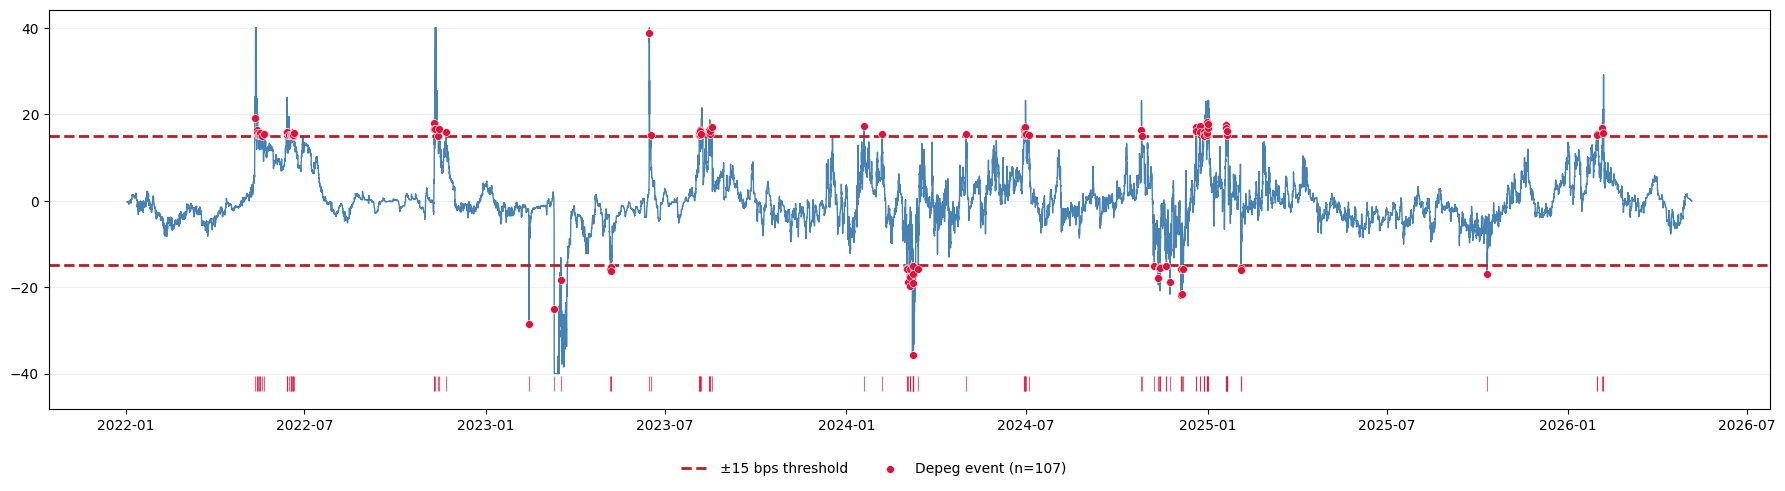

In [5]:
# Figure: realised depeg path and episode onsets.
event_values = context.set_index('timestamp').reindex(event_starts)['depeg_bps']
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(context.timestamp, context.depeg_bps.clip(-40, 40), color='steelblue', lw=1)
ax.axhline(DEPEG_THRESHOLD_BPS, color='firebrick', ls='--', lw=2, label=f'±{DEPEG_THRESHOLD_BPS:g} bps threshold')
ax.axhline(-DEPEG_THRESHOLD_BPS, color='firebrick', ls='--', lw=2)
ax.scatter(event_starts, event_values, color='crimson', edgecolor='white', linewidth=.4,
           s=32, zorder=3, label=f'Depeg event (n={len(event_starts)})')
ax.vlines(event_starts, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[0] + .04 * np.ptp(ax.get_ylim()),
          color='crimson', alpha=.65, lw=.8)
ax.legend(frameon=False, bbox_to_anchor=(0.36, -.1), loc='upper left', ncol=3); ax.grid(axis='y', alpha=.2); fig.tight_layout()
fig.savefig('figure_realised_depeg_events.png', dpi=350, transparent = True, bbox_inches='tight')


,fold,fit_start,fit_end,validation_start,validation_end,test_start,test_end,embargo_hours
0,1,2022-01-02 07:00:00+00:00,2024-01-26 18:00:00+00:00,2024-01-28 18:00:00+00:00,2024-12-15 00:00:00+00:00,2024-12-17 01:00:00+00:00,2026-04-06 12:00:00+00:00,48.0
1,2,2022-01-02 07:00:00+00:00,2024-01-31 22:00:00+00:00,2024-02-02 22:00:00+00:00,2024-12-22 10:00:00+00:00,2024-12-24 11:00:00+00:00,2026-04-13 22:00:00+00:00,48.0
2,3,2022-01-02 07:00:00+00:00,2024-02-06 03:00:00+00:00,2024-02-08 03:00:00+00:00,2024-12-29 20:00:00+00:00,2024-12-31 21:00:00+00:00,2026-04-21 08:00:00+00:00,48.0
3,4,2022-01-02 07:00:00+00:00,2024-02-11 07:00:00+00:00,2024-02-13 07:00:00+00:00,2025-01-06 06:00:00+00:00,2025-01-08 07:00:00+00:00,2026-04-28 18:00:00+00:00,48.0
4,5,2022-01-02 07:00:00+00:00,2024-02-16 12:00:00+00:00,2024-02-18 12:00:00+00:00,2025-01-13 16:00:00+00:00,2025-01-15 17:00:00+00:00,2026-05-06 04:00:00+00:00,48.0


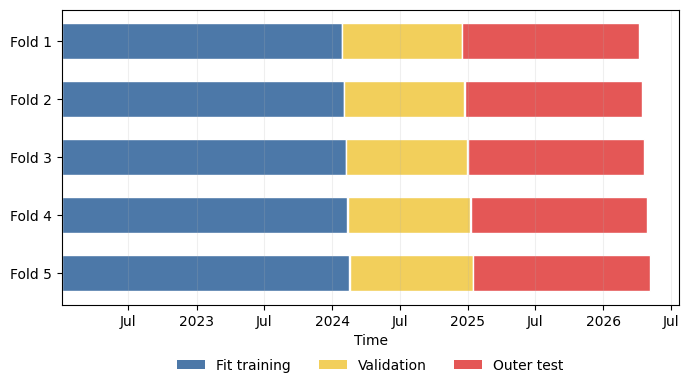

In [9]:
# Figure: fit/validation/test periods for every expanding chronological fold.
split_rows = []
sample_start = context.timestamp.min()
for fold in sorted(scores.fold.unique()):
    validation = scores[(scores.fold == fold) & (scores.split == 'validation')]
    test = scores[(scores.fold == fold) & (scores.split == 'test')]
    fold_row = fold_metrics.loc[fold_metrics.fold == fold].iloc[0]
    embargo_hours = float(fold_row.get('embargo_hours', 24.0))
    split_rows.append({
        'fold': int(fold), 'fit_start': sample_start,
        'fit_end': validation.timestamp.min() - pd.Timedelta(hours=embargo_hours),
        'validation_start': validation.timestamp.min(), 'validation_end': validation.timestamp.max(),
        'test_start': test.timestamp.min(), 'test_end': test.timestamp.max(),
        'embargo_hours': embargo_hours})
split_table = pd.DataFrame(split_rows)
display(split_table)

colors = {'Fit training': '#4C78A8', 'Validation': '#F2CF5B', 'Outer test': '#E45756'}
fig, ax = plt.subplots(figsize=(7, 4))
for y, row in split_table.iterrows():
    intervals = [
        ('Fit training', row.fit_start, row.fit_end),
        ('Validation', row.validation_start, row.validation_end),
        ('Outer test', row.test_start, row.test_end)]
    for label, start, end in intervals:
        left = mdates.date2num(start)
        width = mdates.date2num(end) - left
        ax.barh(y, width, left=left, height=.62, color=colors[label], edgecolor='white')
ax.set_yticks(range(len(split_table)), [f'Fold {x}' for x in split_table.fold])
ax.invert_yaxis(); ax.xaxis_date(); ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.set(xlabel='Time')
ax.legend(handles=[Patch(facecolor=c, label=k) for k, c in colors.items()],
          loc='upper center', bbox_to_anchor=(.5, -.14), ncol=3, frameon=False)
ax.grid(axis='x', alpha=.2); fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_chronological_cv_splits.png', dpi=350, bbox_inches='tight', transparent=True)
plt.show()


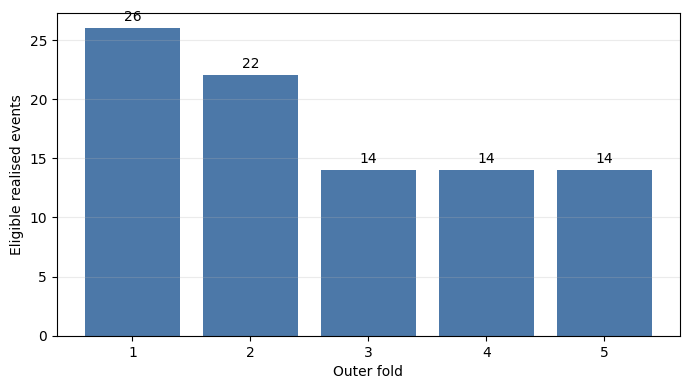

In [10]:
# Figure: denominator of the event-level metrics in each outer fold.
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(event_accounting.fold.astype(str), event_accounting.eligible_events_reconstructed, color='#4C78A8')
ax.bar_label(bars, padding=3)
ax.set(xlabel='Outer fold', ylabel='Eligible realised events')
ax.grid(axis='y', alpha=.25); fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_cv_events_by_fold.png', dpi=350, bbox_inches='tight', transparent=True)
plt.show()


In [13]:
MODEL_LABELS = {'xgboost': 'XGBoost', 'lightgbm': 'LightGBM', 'catboost': 'CatBoost', 'random_forest': 'Random forest'}

def estimate_ci(row, metric, digits=3):
    point = row.get(f'cv_{metric}_mean', np.nan)
    low, high = row.get(f'cv_{metric}_ci_lower', np.nan), row.get(f'cv_{metric}_ci_upper', np.nan)
    if pd.isna(point):
        return 'NA'
    if pd.notna(low) and pd.notna(high):
        return f'{point:.{digits}f} [{low:.{digits}f}, {high:.{digits}f}]'
    return f'{point:.{digits}f}'

table = pd.DataFrame({
    'Model': results.model_name.map(MODEL_LABELS).fillna(results.model_name),
    r'$\alpha$': results.alpha.map(lambda x: f'{x:g}'),
    'Event utility': results.apply(estimate_ci, axis=1, metric='event_utility_score'),
    'Timely event recall': results.apply(estimate_ci, axis=1, metric='timely_event_recall'),
    'False alerts/month': results.apply(lambda r: estimate_ci(r, 'false_alerts_per_month', 2), axis=1),
    'Median lead (h)': results.apply(lambda r: estimate_ci(r, 'median_lead_hours', 1), axis=1),
    'AUC': results.cv_auc_mean.map(lambda x: f'{x:.3f}' if pd.notna(x) else 'NA'),
    'AUPRC': results.cv_auprc_mean.map(lambda x: f'{x:.3f}' if pd.notna(x) else 'NA'),
})
display(table)


,Model,$\alpha$,Event utility,Timely event recall,False alerts/month,Median lead (h),AUC,AUPRC
0,CatBoost,0.3,"0.303 [0.229, 0.381]","0.723 [0.631, 0.819]","2.50 [1.98, 3.01]","14.4 [11.5, 16.5]",0.862,0.241
1,CatBoost,1,"0.281 [0.204, 0.363]","0.746 [0.651, 0.841]","3.07 [2.52, 3.62]","14.5 [11.7, 16.3]",0.853,0.217
2,Random forest,0.5,"0.233 [0.150, 0.308]","0.489 [0.383, 0.593]","1.45 [1.11, 1.82]","14.3 [12.0, 16.5]",0.890,0.204
3,CatBoost,2,"0.226 [0.157, 0.298]","0.685 [0.598, 0.768]","2.70 [2.19, 3.23]","13.0 [9.5, 14.7]",0.862,0.202
4,Random forest,1,"0.222 [0.152, 0.291]","0.515 [0.418, 0.612]","1.79 [1.41, 2.24]","14.6 [10.7, 16.7]",0.887,0.213
5,CatBoost,0.1,"0.208 [0.142, 0.279]","0.568 [0.484, 0.646]","2.30 [1.83, 2.83]","14.0 [10.6, 16.4]",0.855,0.239
6,CatBoost,1.5,"0.183 [0.110, 0.261]","0.589 [0.499, 0.688]","3.10 [2.55, 3.67]","13.5 [10.6, 16.2]",0.842,0.173
7,Random forest,0.1,"0.180 [0.118, 0.243]","0.410 [0.307, 0.504]","0.97 [0.70, 1.27]","12.0 [9.9, 14.9]",0.901,0.239
8,Random forest,2,"0.170 [0.100, 0.241]","0.437 [0.352, 0.530]","1.93 [1.45, 2.42]","15.0 [9.6, 17.8]",0.870,0.180
9,CatBoost,0.5,"0.149 [0.084, 0.206]","0.517 [0.432, 0.599]","2.33 [1.87, 2.87]","9.6 [7.6, 11.2]",0.814,0.172


In [14]:
caption = (
    f'Operational out-of-sample comparison at the {DEPEG_THRESHOLD_BPS:g}-basis-point depeg '
    f'threshold. Probability thresholds are selected on the preceding validation fold subject to an estimated '
    f'budget of at most {FALSE_ALERT_BUDGET:g} false-alert episodes per month; reported false-alert rates are '
    'held-out outcomes and may exceed that validation constraint. Event utility is the '
    'primary selection metric; brackets report event/calendar-block bootstrap 95\\% confidence intervals. '
    'AUC and AUPRC are secondary row-level ranking metrics.'
)
latex = table.to_latex(
    index=False, escape=False, column_format='llrrrrrr', position='!htbp',
    caption=caption, label='tab:cv_model_alpha_results')
latex = latex.replace('\\centering\n', '\\centering\n\\small\n', 1)

tex_path = OUTPUT_DIR / 'table_cv_model_alpha_results.tex'
csv_path = OUTPUT_DIR / 'table_cv_model_alpha_results.csv'
tex_path.write_text(latex)
table.to_csv(csv_path, index=False)
display(Markdown(f'Wrote `{tex_path}` and `{csv_path}`.'))
print(latex)


Wrote `/home/jovyan/cloned_gits/onchain-insights/8. Early-Warning Model/lightning_logs/cv_model_comparison_2026-09-23_15bp/paper_ready/table_cv_model_alpha_results.tex` and `/home/jovyan/cloned_gits/onchain-insights/8. Early-Warning Model/lightning_logs/cv_model_comparison_2026-09-23_15bp/paper_ready/table_cv_model_alpha_results.csv`.

\begin{table}[!htbp]
\caption{Operational out-of-sample comparison at the 15-basis-point depeg threshold. Probability thresholds are selected on the preceding validation fold subject to an estimated budget of at most 2 false-alert episodes per month; reported false-alert rates are held-out outcomes and may exceed that validation constraint. Event utility is the primary selection metric; brackets report event/calendar-block bootstrap 95\% confidence intervals. AUC and AUPRC are secondary row-level ranking metrics.}
\label{tab:cv_model_alpha_results}
\begin{tabular}{llrrrrrr}
\toprule
Model & $\alpha$ & Event utility & Timely event recall & False alerts/month & Median lead (h) & AUC & AUPRC \\
\midrule
CatBoost & 0.3 & 0.303 [0.229, 0.381] & 0.723 [0.631, 0.819] & 2.50 [1.98, 3.01] & 14.4 [11.5, 16.5] & 0.862 & 0.241 \\
CatBoost & 1 & 0.281 [0.204, 0.363] & 0.746 [0.651, 0.841] & 3.07 [2.52, 3.62] & 14.5 [11.7, 16.3] & 0.853 & 0.217 \\
Random forest & 0.5 & 0.233 [0.150, 0.308] & 0.489 [

## Model/α-ordered table with column-wise ranking

This version is ordered by model name and then increasing α. In every metric column, the best value is **bold red** and the second-best distinct value is <span style="color:blue"><u>blue and underlined</u></span>. Higher is better except for false alerts/month, where lower is better.

In [15]:
model_sort = results.model_name.map(MODEL_LABELS).fillna(results.model_name)
ordered_index = results.assign(_model_sort=model_sort).sort_values(['_model_sort', 'alpha']).index
ordered_results = results.loc[ordered_index].reset_index(drop=True)
ordered_table = table.loc[ordered_index].reset_index(drop=True)
styled_table = ordered_table.copy()

# Display column -> (unformatted point-estimate column, higher_is_better).
ranking_columns = {
    'Event utility': ('cv_event_utility_score_mean', True),
    'Timely event recall': ('cv_timely_event_recall_mean', True),
    'False alerts/month': ('cv_false_alerts_per_month_mean', False),
    'Median lead (h)': ('cv_median_lead_hours_mean', True),
    'AUC': ('cv_auc_mean', True),
    'AUPRC': ('cv_auprc_mean', True),
}

def apply_column_ranking(display_column, raw_column, higher_is_better):
    values = pd.to_numeric(ordered_results[raw_column], errors='coerce')
    distinct = np.sort(values.dropna().unique())
    if higher_is_better:
        distinct = distinct[::-1]
    if len(distinct) == 0:
        return
    best, second = distinct[0], distinct[1] if len(distinct) > 1 else None
    for row_index, value in values.items():
        original = styled_table.at[row_index, display_column]
        if pd.notna(value) and np.isclose(value, best):
            styled_table.at[row_index, display_column] = rf'\textcolor{{red}}{{\textbf{{{original}}}}}'
        elif second is not None and pd.notna(value) and np.isclose(value, second):
            styled_table.at[row_index, display_column] = rf'\textcolor{{blue}}{{\underline{{{original}}}}}'

for display_column, (raw_column, higher_is_better) in ranking_columns.items():
    apply_column_ranking(display_column, raw_column, higher_is_better)

ordered_caption = caption + (
    ' Rows are ordered by model and increasing $\alpha$. Best values in each metric are shown '
    'in bold red and second-best distinct values in underlined blue; lower is better for false alerts.'
)
ordered_latex = styled_table.to_latex(
    index=False, escape=False, column_format='llrrrrrr', position='!htbp',
    caption=ordered_caption, label='tab:cv_model_alpha_results_ordered')
ordered_latex = ordered_latex.replace('\\centering\n', '\\centering\n\\small\n', 1)
ordered_latex = '% Requires \\usepackage{xcolor} and \\usepackage{booktabs}.\n' + ordered_latex

ordered_tex_path = OUTPUT_DIR / 'table_cv_model_alpha_results_by_model.tex'
ordered_csv_path = OUTPUT_DIR / 'table_cv_model_alpha_results_by_model.csv'
ordered_tex_path.write_text(ordered_latex)
ordered_table.to_csv(ordered_csv_path, index=False)
display(ordered_table)
display(Markdown(f'Wrote `{ordered_tex_path}` and `{ordered_csv_path}`.'))
print(ordered_latex)


,Model,$\alpha$,Event utility,Timely event recall,False alerts/month,Median lead (h),AUC,AUPRC
0,CatBoost,0.1,"0.208 [0.142, 0.279]","0.568 [0.484, 0.646]","2.30 [1.83, 2.83]","14.0 [10.6, 16.4]",0.855,0.239
1,CatBoost,0.3,"0.303 [0.229, 0.381]","0.723 [0.631, 0.819]","2.50 [1.98, 3.01]","14.4 [11.5, 16.5]",0.862,0.241
2,CatBoost,0.5,"0.149 [0.084, 0.206]","0.517 [0.432, 0.599]","2.33 [1.87, 2.87]","9.6 [7.6, 11.2]",0.814,0.172
3,CatBoost,1,"0.281 [0.204, 0.363]","0.746 [0.651, 0.841]","3.07 [2.52, 3.62]","14.5 [11.7, 16.3]",0.853,0.217
4,CatBoost,1.5,"0.183 [0.110, 0.261]","0.589 [0.499, 0.688]","3.10 [2.55, 3.67]","13.5 [10.6, 16.2]",0.842,0.173
5,CatBoost,2,"0.226 [0.157, 0.298]","0.685 [0.598, 0.768]","2.70 [2.19, 3.23]","13.0 [9.5, 14.7]",0.862,0.202
6,LightGBM,0.1,"-0.071 [-0.096, -0.047]","0.030 [0.000, 0.066]","1.60 [1.17, 2.07]","6.0 [3.5, 8.5]",0.545,0.036
7,LightGBM,0.3,"-0.037 [-0.064, -0.010]","0.054 [0.023, 0.085]","1.19 [0.83, 1.64]","4.0 [1.0, 20.0]",0.579,0.044
8,LightGBM,0.5,"-0.124 [-0.158, -0.090]","0.032 [0.008, 0.064]","2.69 [2.06, 3.35]","6.5 [4.0, 8.5]",0.543,0.031
9,LightGBM,1,"-0.096 [-0.143, -0.041]","0.105 [0.048, 0.170]","3.05 [2.42, 3.66]","11.8 [6.0, 15.2]",0.602,0.043


Wrote `/home/jovyan/cloned_gits/onchain-insights/8. Early-Warning Model/lightning_logs/cv_model_comparison_2026-09-23_15bp/paper_ready/table_cv_model_alpha_results_by_model.tex` and `/home/jovyan/cloned_gits/onchain-insights/8. Early-Warning Model/lightning_logs/cv_model_comparison_2026-09-23_15bp/paper_ready/table_cv_model_alpha_results_by_model.csv`.

% Requires \usepackage{xcolor} and \usepackage{booktabs}.
\begin{table}[!htbp]
\caption{Operational out-of-sample comparison at the 15-basis-point depeg threshold. Probability thresholds are selected on the preceding validation fold subject to an estimated budget of at most 2 false-alert episodes per month; reported false-alert rates are held-out outcomes and may exceed that validation constraint. Event utility is the primary selection metric; brackets report event/calendar-block bootstrap 95\% confidence intervals. AUC and AUPRC are secondary row-level ranking metrics. Rows are ordered by model and increasing $lpha$. Best values in each metric are shown in bold red and second-best distinct values in underlined blue; lower is better for false alerts.}
\label{tab:cv_model_alpha_results_ordered}
\begin{tabular}{llrrrrrr}
\toprule
Model & $\alpha$ & Event utility & Timely event recall & False alerts/month & Median lead (h) & AUC & AUPRC \\
\midrule
CatBoost & 0.1 & 0.208 [0.142, 0.279] &